## 1. Setup & Data Loading
Install dependency, setup Kaggle API, dan download dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

if 'kaggle.json' in uploaded:
    print('kaggle.json berhasil diupload')
else:
    print('File yang diupload bukan kaggle.json')
    print('File yang diupload:', list(uploaded.keys()))


Saving kaggle.json to kaggle (1).json
File yang diupload bukan kaggle.json
File yang diupload: ['kaggle (1).json']


In [ ]:
import os, json, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
possible_paths = [
    'kaggle.json',
    '/content/kaggle.json',
    '/root/kaggle.json',
]

kaggle_src = None
for p in possible_paths:
    if os.path.exists(p):
        kaggle_src = p
        break

if kaggle_src:
    shutil.copy(kaggle_src, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    with open('/root/.kaggle/kaggle.json') as f:
        creds = json.load(f)
    print(f'kaggle.json terpasang! Username: {creds["username"]}')
else:
    print('kaggle.json tidak ditemukan')
    print('Pastikan sudah upload kaggle.json di cell sebelumnya')

os.system('pip install kaggle timm albumentations -q')
print('Packages installed!')


kaggle.json terpasang! Username: winsonjonathan1
Packages installed!


In [ ]:
import zipfile, glob, os

COMP_NAME = 'data-analytics-competition-dac-find-it-2026-resubmissio'
print('Downloading dataset...')
ret = os.system(f'kaggle competitions download -c {COMP_NAME}')

if ret != 0:
    print('Download gagal')
else:
    zip_files = glob.glob('*.zip')
    if not zip_files:
        print('File zip tidak ditemukan setelah download!')
    else:
        zip_file = zip_files[0]
        print(f'Extracting: {zip_file}')
        with zipfile.ZipFile(zip_file, 'r') as z:
            z.extractall('./data')
        print('Dataset berhasil di-extract ke folder ./data')
        for item in sorted(os.listdir('./data')):
            print(f'{item}')


Extracting: data-analytics-competition-dac-find-it-2026-resubmissio.zip
Dataset berhasil di-extract ke folder ./data
samplesubmission.csv
test
train


## 2. Data Exploration
Melihat struktur folder dan distribusi kelas.

=== Distribusi Dataset ===
  realperson: 465 gambar
  fake_printed: 118 gambar
  fake_screen: 229 gambar
  fake_mask: 278 gambar
  fake_mannequin: 224 gambar
  fake_unknown: 338 gambar

Total train : 1652
Total test  : 404


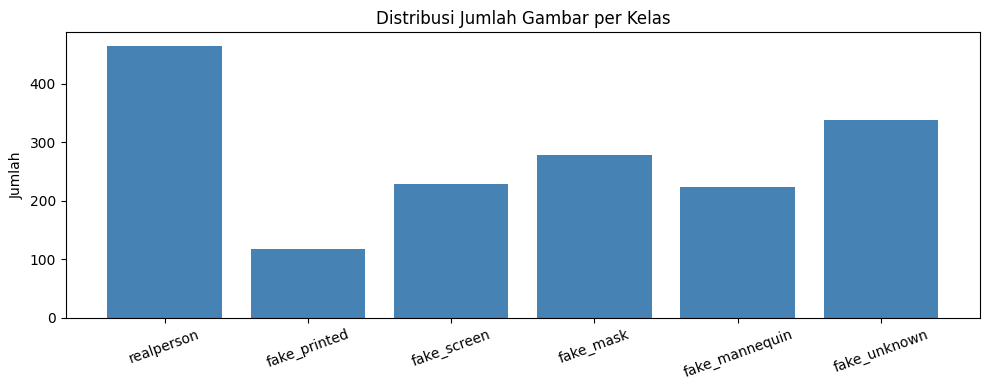

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2, random
from collections import Counter

CLASSES = ['realperson', 'fake_printed', 'fake_screen',
           'fake_mask', 'fake_mannequin', 'fake_unknown']

print("=== Distribusi Dataset ===")
class_counts = {}
for cls in CLASSES:
    path = f'./data/train/{cls}'
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    class_counts[cls] = count
    print(f'  {cls}: {count} gambar')

print(f"\nTotal train : {sum(class_counts.values())}")
print(f"Total test  : {len(os.listdir('./data/test'))}")
plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xticks(rotation=20)
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

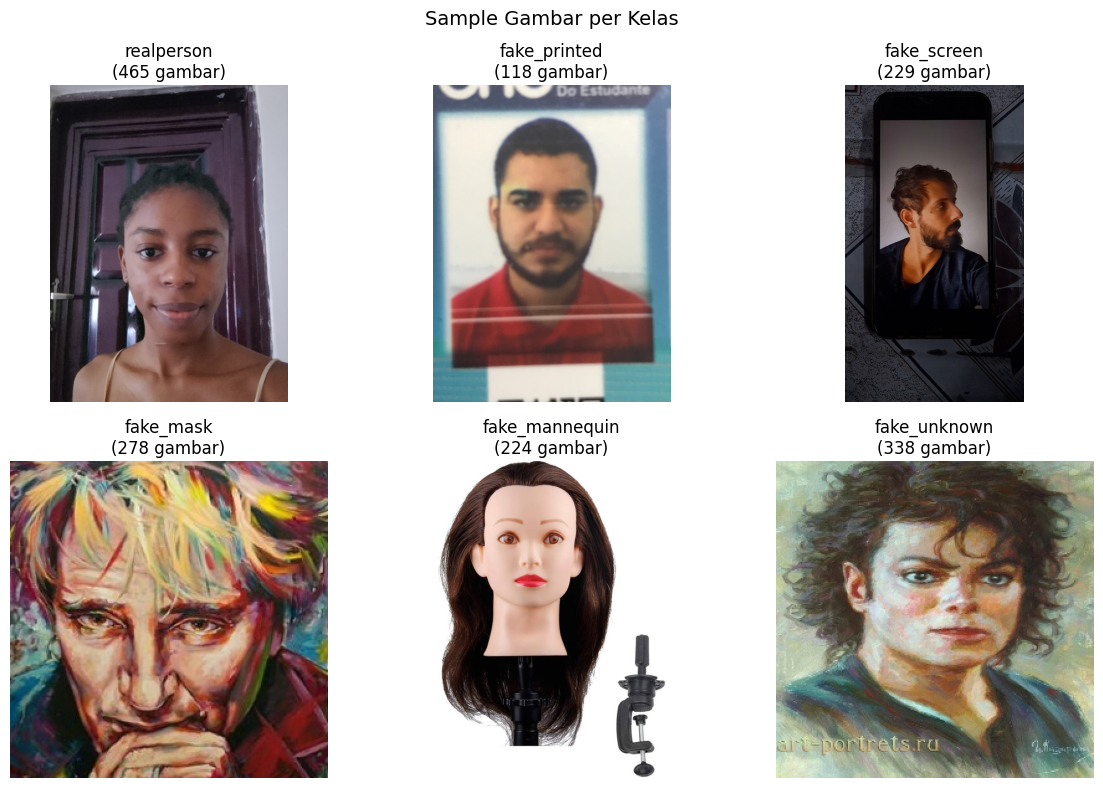

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, cls in enumerate(CLASSES):
    cls_path = f'./data/train/{cls}'
    img_file = random.choice(os.listdir(cls_path))
    img = cv2.imread(os.path.join(cls_path, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n({class_counts[cls]} gambar)')
    axes[i].axis('off')
plt.suptitle('Sample Gambar per Kelas', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Environment Setup
Import semua library dan cek device GPU.

In [ ]:
import gc, os, torch, timm
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from timm.data.mixup import Mixup
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch version :", torch.__version__)
print("Device          :", device)
if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
    free_vram = torch.cuda.mem_get_info()[0] / 1e9
    print(f"VRAM Free       : {free_vram:.2f} GB")

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU Name        : Tesla T4
VRAM Free       : 0.01 GB


## 4. Data Preprocessing & Augmentasi

- **Training:** Resize 384, flip, rotasi, color jitter, grayscale, normalisasi
- **Validation / TTA:** Hanya resize dan normalisasi
- **TTA (Test Time Augmentation):** 4 variasi transform saat inference

In [ ]:
IMG_SIZE = 384
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
    transforms.Compose([
        transforms.Resize((int(IMG_SIZE*1.1), int(IMG_SIZE*1.1))),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
]

print(f"Image size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"TTA variants  : {len(tta_transforms)}")

Image size    : 384x384
TTA variants  : 4


## 5. Dataset Loading & Class Imbalance Handling

- Load dataset dengan `ImageFolder`
- Hitung `class_weights` otomatis dari distribusi data
- Setup `WeightedRandomSampler` agar setiap batch lebih seimbang
- Setup Mixup + CutMix augmentation

In [ ]:
full_dataset = datasets.ImageFolder(root='/content/data/train', transform=train_transform)
labels_list  = [s[1] for s in full_dataset.samples]
label_counts  = Counter(labels_list)
total         = sum(label_counts.values())
import math
weights_list  = [math.sqrt(total / label_counts[i]) for i in range(len(label_counts))]
class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

mixup_fn = Mixup(
    mixup_alpha=0.4,
    cutmix_alpha=1.0,
    prob=0.7,
    switch_prob=0.5,
    mode='batch',
    num_classes=6
)

print("Classes      :", full_dataset.classes)
print("Class weights:", [f'{w:.2f}' for w in weights_list])
print("Total samples:", total)

Classes      : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']
Class weights: ['2.72', '2.44', '3.74', '2.69', '2.21', '1.88']
Total samples: 1652


## 6. Custom Dataset untuk Test

In [ ]:
class TestDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        self.folder = folder
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.files[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx]

print("TestDataset class defined.")

TestDataset class defined.


## 7. Fungsi Validasi

In [ ]:
from sklearn.metrics import f1_score

def val_epoch(model, loader, criterion):
    """Validasi: kembalikan loss + Macro F1 + Accuracy"""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return total_loss / len(loader), macro_f1, acc

print('val_epoch (Macro F1) defined.')


val_epoch (Macro F1) defined.


In [ ]:
from torchvision import transforms

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

from torchvision import datasets
full_dataset = datasets.ImageFolder(root='/content/data/train', transform=train_transform)

print(f"Transform reset ke {IMG_SIZE}x{IMG_SIZE}")
print(f"Dataset reloaded: {len(full_dataset)} samples")

sample_img, _ = full_dataset[0]
print(f"Sample image shape: {sample_img.shape}")

Transform reset ke 224x224
Dataset reloaded: 1652 samples
Sample image shape: torch.Size([3, 224, 224])


## 8. Training: Stratified 5-Fold Cross Validation

- Model: `swin_large_patch4_window12_384` (lebih besar dari swin_base)
- Input size: 384×384 (lebih detail)
- Optimizer: AdamW dengan lr=5e-5
- Scheduler: `OneCycleLR` dengan warmup 10%
- Gradient clipping: max_norm=1.0
- Label smoothing: 0.2
- WeightedRandomSampler untuk imbalance
- Dropout + drop_path 0.3
- Early stopping patience=7

In [ ]:
BATCH_SIZE   = 8
ACCUM_STEPS  = 4
N_EPOCHS     = 30
PATIENCE     = 7
N_FOLDS      = 5
MODEL_NAME   = 'swin_base_patch4_window7_224'

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(full_dataset)), labels_list)):
    print(f'\n{"="*50}')
    print(f'  FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*50}')

    torch.cuda.empty_cache()
    gc.collect()

    train_sub = Subset(full_dataset, train_idx)
    val_dataset_fold = datasets.ImageFolder('/content/data/train', transform=val_transform)
    val_sub = Subset(val_dataset_fold, val_idx)

    train_labels_fold = [labels_list[i] for i in train_idx]
    sample_weights = [weights_list[l] for l in train_labels_fold]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader_fold = DataLoader(
        train_sub, batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=2, drop_last=True, pin_memory=True
    )
    val_loader_fold = DataLoader(
        val_sub, batch_size=BATCH_SIZE*2, shuffle=False,
        num_workers=2, pin_memory=True
    )

    model_fold = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=6,
        drop_rate=0.3,
        drop_path_rate=0.2
    )
    model_fold = model_fold.to(device)

    if torch.cuda.is_available():
        free_gb = torch.cuda.mem_get_info()[0] / 1e9
        print(f'  VRAM free setelah load model: {free_gb:.2f} GB')

    optimizer_fold = torch.optim.AdamW(
        model_fold.parameters(), lr=5e-5, weight_decay=0.05
    )
    effective_steps = len(train_loader_fold) // ACCUM_STEPS
    scheduler_fold = torch.optim.lr_scheduler.OneCycleLR(
        optimizer_fold,
        max_lr=1e-4,
        steps_per_epoch=effective_steps,
        epochs=N_EPOCHS,
        pct_start=0.1
    )
    criterion_fold = nn.CrossEntropyLoss(
        weight=class_weights, label_smoothing=0.15
    )

    best_f1_fold = 0
    no_improve   = 0

    for epoch in range(N_EPOCHS):
        model_fold.train()
        optimizer_fold.zero_grad()
        for step, (images, lbls) in enumerate(train_loader_fold):
            images, lbls = images.to(device), lbls.to(device)
            images, lbls_mixed = mixup_fn(images, lbls)
            outputs = model_fold(images)
            loss = criterion_fold(outputs, lbls_mixed)
            loss = loss / ACCUM_STEPS
            loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
                optimizer_fold.step()
                scheduler_fold.step()
                optimizer_fold.zero_grad()
        val_loss, val_f1, val_acc = val_epoch(model_fold, val_loader_fold, criterion_fold)
        if val_f1 > best_f1_fold:
            best_f1_fold = val_f1
            no_improve = 0
            torch.save(model_fold.state_dict(), f'best_fold{fold+1}.pth')
        else:
            no_improve += 1

        print(f'  Epoch {epoch+1:2d}/{N_EPOCHS} | Loss: {val_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f} | Best F1: {best_f1_fold:.4f}')

        if no_improve >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    print(f'\n  Fold {fold+1} Best Val Macro F1: {best_f1_fold:.4f}')

    del model_fold, optimizer_fold, scheduler_fold, criterion_fold
    del train_loader_fold, val_loader_fold, train_sub, val_sub, val_dataset_fold
    torch.cuda.empty_cache()
    gc.collect()

print('\n=== Semua fold selesai! ===')



  FOLD 1/5
  VRAM free setelah load model: 13.69 GB
  Epoch  1/30 | Loss: 1.5598 | F1: 0.5635 | Acc: 0.5740 | Best F1: 0.5635
  Epoch  2/30 | Loss: 1.1056 | F1: 0.8065 | Acc: 0.8187 | Best F1: 0.8065
  Epoch  3/30 | Loss: 1.0573 | F1: 0.7998 | Acc: 0.8127 | Best F1: 0.8065
  Epoch  4/30 | Loss: 1.0549 | F1: 0.8100 | Acc: 0.8187 | Best F1: 0.8100
  Epoch  5/30 | Loss: 1.0239 | F1: 0.8151 | Acc: 0.8278 | Best F1: 0.8151
  Epoch  6/30 | Loss: 1.0308 | F1: 0.8385 | Acc: 0.8550 | Best F1: 0.8385
  Epoch  7/30 | Loss: 1.0607 | F1: 0.7960 | Acc: 0.8187 | Best F1: 0.8385
  Epoch  8/30 | Loss: 1.0368 | F1: 0.8057 | Acc: 0.8278 | Best F1: 0.8385
  Epoch  9/30 | Loss: 1.0102 | F1: 0.8155 | Acc: 0.8399 | Best F1: 0.8385
  Epoch 10/30 | Loss: 1.0532 | F1: 0.8081 | Acc: 0.8248 | Best F1: 0.8385
  Epoch 11/30 | Loss: 1.0271 | F1: 0.8038 | Acc: 0.8248 | Best F1: 0.8385
  Epoch 12/30 | Loss: 1.0355 | F1: 0.8075 | Acc: 0.8248 | Best F1: 0.8385
  Epoch 13/30 | Loss: 1.0554 | F1: 0.8129 | Acc: 0.8278 | B

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch, timm, gc
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

MODEL_NAME = 'swin_base_patch4_window7_224'
CLASSES = full_dataset.classes

all_fold_reports = []

for fold in range(N_FOLDS):
    print(f"\n{'='*40}")
    print(f"  Analisis FOLD {fold+1}")
    print(f"{'='*40}")
    m = timm.create_model(MODEL_NAME, pretrained=False, num_classes=6,
                          drop_rate=0.3, drop_path_rate=0.2)
    m.load_state_dict(torch.load(f'best_fold{fold+1}.pth', map_location=device))
    m = m.to(device)
    m.eval()
    _, val_idx = list(skf.split(range(len(full_dataset)), labels_list))[fold]
    val_ds = datasets.ImageFolder('/content/data/train', transform=val_transform)
    val_sub = Subset(val_ds, val_idx)
    val_ld  = DataLoader(val_sub, batch_size=16, shuffle=False, num_workers=2)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_ld:
            images = images.to(device)
            preds  = m(images).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=3))
    all_fold_reports.append((all_labels, all_preds))

    del m
    torch.cuda.empty_cache()
    gc.collect()


  Analisis FOLD 1
                precision    recall  f1-score   support

fake_mannequin      0.875     0.933     0.903        45
     fake_mask      0.863     0.786     0.822        56
  fake_printed      0.708     0.739     0.723        23
   fake_screen      0.900     0.783     0.837        46
  fake_unknown      0.822     0.882     0.851        68
    realperson      0.884     0.903     0.894        93

      accuracy                          0.855       331
     macro avg      0.842     0.838     0.838       331
  weighted avg      0.857     0.855     0.854       331


  Analisis FOLD 2
                precision    recall  f1-score   support

fake_mannequin      0.690     0.889     0.777        45
     fake_mask      0.789     0.804     0.796        56
  fake_printed      0.486     0.739     0.586        23
   fake_screen      0.841     0.804     0.822        46
  fake_unknown      0.770     0.691     0.729        68
    realperson      0.842     0.688     0.757        93

     

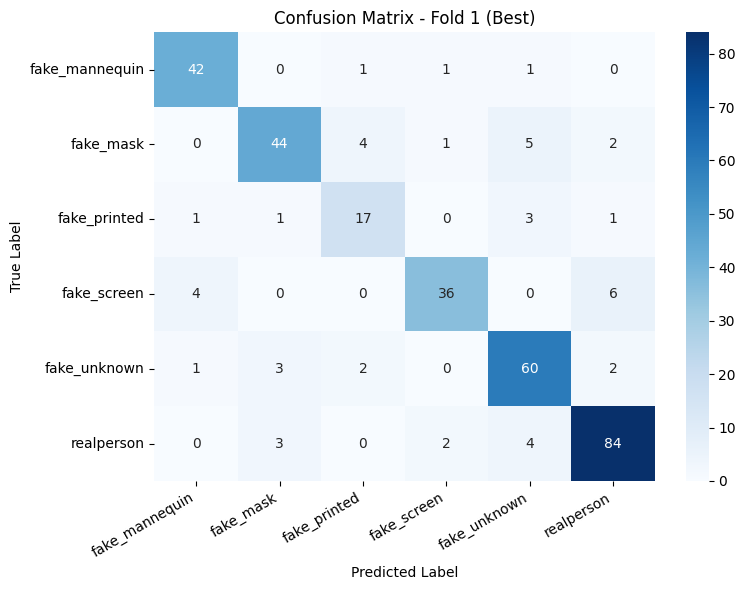

In [ ]:
labels_f1, preds_f1 = all_fold_reports[0]

cm = confusion_matrix(labels_f1, preds_f1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Fold 1 (Best)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import torch, timm, gc, os
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from collections import Counter
from timm.data.mixup import Mixup

IMG_SIZE    = 224
BATCH_SIZE  = 8
ACCUM_STEPS = 4
N_FOLDS     = 5
EPOCHS      = 35
LR          = 2e-4
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.backends.cudnn.benchmark = True

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        if targets.dim() > 1:
            log_prob = torch.nn.functional.log_softmax(inputs, dim=-1)
            loss = -(targets * log_prob).sum(dim=-1)
            return loss.mean()
        ce = torch.nn.functional.cross_entropy(
            inputs, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((256, 256)), transforms.CenterCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
    transforms.Compose([
        transforms.Resize((270, 270)), transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
    transforms.Compose([
        transforms.Resize((256, 256)), transforms.CenterCrop(IMG_SIZE),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)
    ]),
]


full_dataset = datasets.ImageFolder('/content/data/train', transform=train_transform)
labels_list  = [s[1] for s in full_dataset.samples]
CLASSES      = full_dataset.classes
N_CLASSES    = len(CLASSES)
print(f"Kelas: {CLASSES}")


label_counts  = Counter(labels_list)
total_samples = len(labels_list)
weights_arr   = [total_samples / (N_CLASSES * label_counts[i]) for i in range(N_CLASSES)]
class_weights = torch.tensor(weights_arr, dtype=torch.float).to(DEVICE)
print(f"Class weights: {[f'{w:.2f}' for w in weights_arr]}")

mixup_fn = Mixup(
    mixup_alpha=0.2,
    cutmix_alpha=0.0,
    prob=0.5,
    num_classes=N_CLASSES
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

best_f1_overall  = 0.0
fold_f1_scores   = []

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(full_dataset)), labels_list)):
    print(f"\n{'='*52}")
    print(f"  FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*52}")

    torch.cuda.empty_cache(); gc.collect()
    fold_labels     = [labels_list[i] for i in train_idx]
    sample_weights  = [weights_arr[l] for l in fold_labels]
    sampler         = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_sub = Subset(full_dataset, train_idx)
    val_ds    = datasets.ImageFolder('/content/data/train', transform=val_transform)
    val_sub   = Subset(val_ds, val_idx)

    train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_sub,   batch_size=16,         shuffle=False,
                              num_workers=2, pin_memory=True)

    model_fold = timm.create_model(
        'swin_base_patch4_window7_224',
        pretrained=True,
        num_classes=N_CLASSES,
        drop_rate=0.3,
        drop_path_rate=0.2
    ).to(DEVICE)

    free_gb = torch.cuda.mem_get_info()[0] / 1e9
    print(f"  VRAM free setelah load model: {free_gb:.2f} GB")

    criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.12)

    optimizer = torch.optim.AdamW(model_fold.parameters(), lr=LR, weight_decay=1e-2)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR,
        steps_per_epoch=len(train_loader) // ACCUM_STEPS,
        epochs=EPOCHS,
        pct_start=0.15,
        anneal_strategy='cos'
    )

    scaler    = torch.cuda.amp.GradScaler()
    best_f1   = 0.0
    patience  = 8
    no_improve = 0
    for epoch in range(EPOCHS):
        model_fold.train()
        total_loss = 0.0
        optimizer.zero_grad()

        for step, (images, lbls) in enumerate(train_loader):
            images, lbls = images.to(DEVICE), lbls.to(DEVICE)

            images, lbls_mixed = mixup_fn(images, lbls)

            with torch.cuda.amp.autocast():
                outputs = model_fold(images)
                loss    = criterion(outputs, lbls_mixed) / ACCUM_STEPS

            scaler.scale(loss).backward()
            total_loss += loss.item() * ACCUM_STEPS

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        model_fold.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                with torch.cuda.amp.autocast():
                    outputs = model_fold(images)
                preds = outputs.argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        avg_loss = total_loss / len(train_loader)
        val_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        val_acc  = np.mean(np.array(all_preds) == np.array(all_labels))

        print(f"  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"F1: {val_f1:.4f} | Acc: {val_acc:.4f} | Best F1: {best_f1:.4f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            no_improve = 0
            torch.save(model_fold.state_dict(), f'best_fold{fold+1}.pth')
            print(f"Model fold {fold+1} tersimpan! F1: {best_f1:.4f}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping di epoch {epoch+1}")
                break

    fold_f1_scores.append(best_f1)
    print(f"\nFold {fold+1} Best F1: {best_f1:.4f}")

    del model_fold, optimizer, scheduler, scaler
    torch.cuda.empty_cache(); gc.collect()

print(f"\n{'='*52}")
print(f"  CV RESULTS")
print(f"{'='*52}")
for i, f1 in enumerate(fold_f1_scores):
    print(f"  Fold {i+1}: {f1:.4f}")
print(f"  Mean F1 : {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")

Kelas: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']
Class weights: ['1.23', '0.99', '2.33', '1.20', '0.81', '0.59']

  FOLD 1/5
  VRAM free setelah load model: 13.88 GB
  Epoch  1/35 | Loss: 1.7708 | F1: 0.5606 | Acc: 0.5650 | Best F1: 0.0000
Model fold 1 tersimpan! F1: 0.5606
  Epoch  2/35 | Loss: 1.3351 | F1: 0.7739 | Acc: 0.7764 | Best F1: 0.5606
Model fold 1 tersimpan! F1: 0.7739
  Epoch  3/35 | Loss: 1.1152 | F1: 0.7622 | Acc: 0.7674 | Best F1: 0.7739
  Epoch  4/35 | Loss: 1.0685 | F1: 0.7199 | Acc: 0.7251 | Best F1: 0.7739
  Epoch  5/35 | Loss: 1.0684 | F1: 0.7906 | Acc: 0.7976 | Best F1: 0.7739
Model fold 1 tersimpan! F1: 0.7906
  Epoch  6/35 | Loss: 0.9919 | F1: 0.7389 | Acc: 0.7613 | Best F1: 0.7906
  Epoch  7/35 | Loss: 0.9190 | F1: 0.7506 | Acc: 0.7553 | Best F1: 0.7906
  Epoch  8/35 | Loss: 0.9345 | F1: 0.7855 | Acc: 0.8066 | Best F1: 0.7906
  Epoch  9/35 | Loss: 0.9034 | F1: 0.7594 | Acc: 0.7915 | Best F1: 0.7906
  Epoch 10/3

## 8b. Cek Model Sebelum Inference
Pastikan semua model tersimpan sebelum lanjut ke inference.

In [ ]:
import os
print('=== Cek File Model Tersimpan ===')
total_size = 0
all_saved = True
for fold in range(1, N_FOLDS + 1):
    fname = f'best_fold{fold}.pth'
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / 1e6
        total_size += size_mb
        print(f'{fname}  ({size_mb:.1f} MB)')
    else:
        print(f'{fname}  BELUM ADA!')
        all_saved = False
print(f'Total ukuran model: {total_size:.1f} MB')
print('Lanjut Inference!' if all_saved else 'Ada fold belum selesai!')


=== Cek File Model Tersimpan ===
best_fold1.pth  (347.1 MB)
best_fold2.pth  (347.1 MB)
best_fold3.pth  (347.1 MB)
best_fold4.pth  (347.1 MB)
best_fold5.pth  (347.1 MB)
Total ukuran model: 1735.6 MB
Lanjut Inference!


## 9. Inference: Ensemble 5-Fold + TTA

- Load model terbaik dari tiap fold
- Jalankan inference dengan 4 TTA transforms
- Rata-ratakan probabilitas antar TTA dan antar fold (ensemble)
- Ambil kelas dengan probabilitas tertinggi sebagai prediksi final

In [ ]:
all_probs     = None
all_filenames = None

for fold in range(N_FOLDS):
    print(f"Inference Fold {fold+1}/{N_FOLDS}...")
    m = timm.create_model(
        MODEL_NAME, pretrained=False, num_classes=6,
        drop_rate=0.3, drop_path_rate=0.3
    )
    m.load_state_dict(torch.load(f'best_fold{fold+1}.pth'))
    m = m.to(device)
    m.eval()

    fold_probs = None

    for tta_idx, tta_tf in enumerate(tta_transforms):
        test_ds = TestDataset('/content/data/test', transform=tta_tf)
        test_ld = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        tta_probs = []
        tta_files = []

        with torch.no_grad():
            for images, filenames in test_ld:
                images = images.to(device)
                probs  = torch.softmax(m(images), dim=1).cpu()
                tta_probs.append(probs)
                tta_files.extend(filenames)

        tta_probs = torch.cat(tta_probs, dim=0)
        if fold == 0 and tta_idx == 0:
            all_filenames = tta_files

        fold_probs = tta_probs if fold_probs is None else fold_probs + tta_probs

    fold_probs /= len(tta_transforms)

    all_probs = fold_probs if all_probs is None else all_probs + fold_probs

    del m
    torch.cuda.empty_cache()
    gc.collect()

all_probs /= N_FOLDS

print(f"\nProbs shape     : {all_probs.shape}")
print(f"Filenames count : {len(all_filenames)}")
assert all_probs.shape[0] == len(all_filenames), "ERROR: Jumlah prediksi dan filename tidak sama!"
print("Assertion passed ✓")

Inference Fold 1/5...
Inference Fold 2/5...
Inference Fold 3/5...
Inference Fold 4/5...
Inference Fold 5/5...

Probs shape     : torch.Size([404, 6])
Filenames count : 404
Assertion passed ✓


## 10. Membuat File Submission

In [ ]:
from sklearn.metrics import classification_report

preds = all_probs.argmax(dim=1).numpy()
ref_dataset = datasets.ImageFolder('/content/data/train', transform=val_transform)
class_names = ref_dataset.classes
pred_labels = [class_names[p] for p in preds]

submission = pd.DataFrame({'filename': all_filenames, 'label': pred_labels})
submission['id'] = (submission['filename']
    .str.replace('.jpg',  '', regex=False)
    .str.replace('.jpeg', '', regex=False)
    .str.replace('.png',  '', regex=False))
submission = submission[['id', 'label']]
submission.to_csv('submission_final.csv', index=False)

print('=== Submission Preview ===')
print(submission.head(10))
print(f'\nTotal data: {len(submission)}')

print('\nDistribusi prediksi (penting untuk Macro F1):')
dist = submission['label'].value_counts()
print(dist)

CLASSES = ['realperson','fake_printed','fake_screen','fake_mask','fake_mannequin','fake_unknown']
missing = [c for c in CLASSES if c not in dist.index]
if missing:
    print(f'\nKELAS TIDAK DIPREDIKSI: {missing}')
    print('   Macro F1 akan sangat rendah! Cek ulang model.')
else:
    print('\nSemua 6 kelas terprediksi.')


=== Submission Preview ===
         id           label
0  test_001     fake_screen
1  test_002     fake_screen
2  test_003       fake_mask
3  test_004      realperson
4  test_005    fake_printed
5  test_006  fake_mannequin
6  test_007       fake_mask
7  test_008  fake_mannequin
8  test_009       fake_mask
9  test_010     fake_screen

Total data: 404

Distribusi prediksi (penting untuk Macro F1):
label
realperson        100
fake_mask          74
fake_screen        66
fake_printed       59
fake_mannequin     56
fake_unknown       49
Name: count, dtype: int64

Semua 6 kelas terprediksi.


## 11. Submit ke Kaggle

In [ ]:
!kaggle competitions submit \
  -c data-analytics-competition-dac-find-it-2026-resubmissio \
  -f submission_final.csv \
  -m "SwinLarge 5-Fold MacroF1 + TTA4x, img=384, sqrtWeights, ls=0.15"


100% 8.32k/8.32k [00:00<00:00, 11.9kB/s]
Successfully submitted to Data Analytics Competition (DAC) Find IT! 2026 - Resubmissio